# Notebook 05 — Predictive Maintenance
**Datasets:**
- `data/raw/telematics/telematics.csv` — synthetic vehicle sensors (generated by `scripts/make_telematics_data.py`)
- `data/raw/maintenance/aps_failure_training_set.csv` — Scania APS real failure data (171 sensor features, ~60k rows)
- `data/raw/maintenance/aps_failure_test_set.csv` — APS test set (~16k rows)

**Pipeline:** IsolationForest (anomaly detection) → calibrated 0–100 risk score + Random Forest classifier


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings, os
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)
sns.set_theme(style='whitegrid')
print('Ready')


Ready


---
## 1. Telematics Data (Synthetic)


In [20]:
import subprocess, sys
if not os.path.exists('../data/raw/telematics/telematics.csv'):
    subprocess.run([sys.executable,'scripts/make_telematics_data.py'], check=True)
tel = pd.read_csv('../data/raw/telematics/telematics.csv')
print(f'Shape: {tel.shape}  |  Failure rate: {tel["failure_label"].mean():.1%}')
tel.head(3)


Shape: (600, 15)  |  Failure rate: 19.0%


,vehicle_id,odometer_km,avg_speed_kmh,max_speed_kmh,engine_temp_mean_c,engine_temp_max_c,battery_voltage_mean,battery_voltage_min,vibration_mean_ms2,vibration_max_ms2,brake_pressure_mean,hard_brakes_count,idle_hours,trips_count,failure_label
0,V0001,298046.0,65.7,104.0,96.8,109.0,11.77,10.50,1.295,1.825,9.93,6,332.9,608,1
1,V0002,24745.0,60.5,94.6,92.3,98.8,12.77,11.55,0.385,1.328,8.94,5,124.7,520,0
2,V0003,281333.0,44.8,113.4,93.4,115.0,13.75,12.58,0.689,1.768,7.91,6,107.2,559,0


---
## 2. Telematics Feature Prep


In [21]:
TEL_FEATURES = ['odometer_km','avg_speed_kmh','max_speed_kmh',
                 'engine_temp_mean_c','engine_temp_max_c',
                 'battery_voltage_mean','battery_voltage_min',
                 'vibration_mean_ms2','vibration_max_ms2',
                 'brake_pressure_mean','hard_brakes_count','idle_hours','trips_count']
X_t = tel[TEL_FEATURES].values; y_t = tel['failure_label'].values
X_tr, X_te, y_tr, y_te = train_test_split(X_t, y_t, test_size=0.2, stratify=y_t, random_state=42)
sc_t = StandardScaler()
X_tr_s = sc_t.fit_transform(X_tr); X_te_s = sc_t.transform(X_te)
print(f'Train: {X_tr.shape}  Test: {X_te.shape}')


Train: (480, 13)  Test: (120, 13)


---
## 3. IsolationForest — Anomaly Score


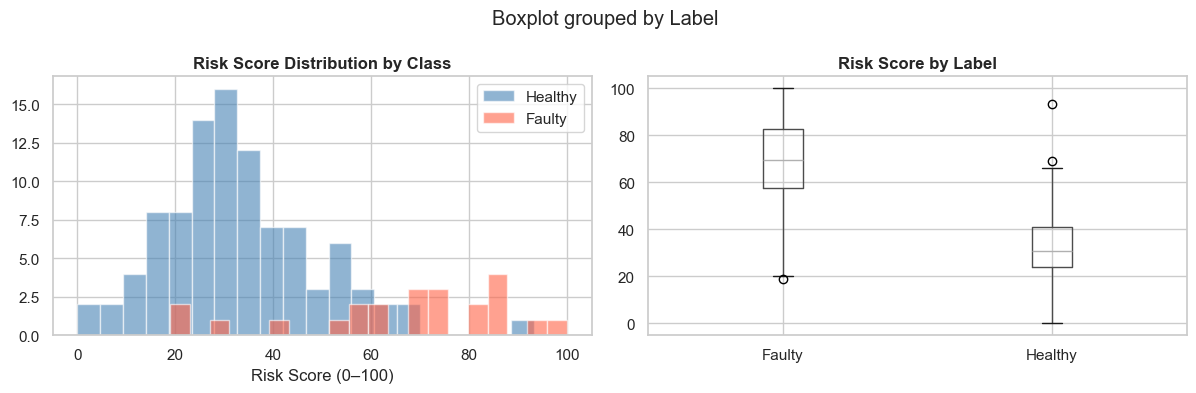

              precision    recall  f1-score   support

     Healthy       0.95      0.86      0.90        97
      Faulty       0.58      0.83      0.68        23

    accuracy                           0.85       120
   macro avg       0.76      0.84      0.79       120
weighted avg       0.88      0.85      0.86       120



In [22]:
iso = IsolationForest(n_estimators=200, contamination=0.15, random_state=42, n_jobs=-1)
iso.fit(X_tr_s[y_tr == 0])   # train only on healthy vehicles
raw_scores = iso.decision_function(X_te_s)
risk_scores = 100 * (1 - (raw_scores - raw_scores.min()) /
                     (raw_scores.max() - raw_scores.min() + 1e-9))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, name, color in [(0,'Healthy','steelblue'),(1,'Faulty','tomato')]:
    axes[0].hist(risk_scores[y_te==label], bins=20, alpha=0.6, label=name, color=color)
axes[0].set_title('Risk Score Distribution by Class', fontweight='bold')
axes[0].set_xlabel('Risk Score (0–100)'); axes[0].legend()
pd.DataFrame({'Risk':risk_scores,'Label':['Faulty' if l else 'Healthy' for l in y_te]})\
  .boxplot(column='Risk', by='Label', ax=axes[1])
axes[1].set_title('Risk Score by Label', fontweight='bold'); axes[1].set_xlabel('')
plt.tight_layout(); plt.savefig('../data/processed/maintenance_iso.png', bbox_inches='tight')
plt.show()
from sklearn.metrics import classification_report
iso_preds = (risk_scores > 50).astype(int)
print(classification_report(y_te, iso_preds, target_names=['Healthy','Faulty']))


---
## 4. Random Forest Classifier (Telematics)


              precision    recall  f1-score   support

     Healthy       0.88      0.99      0.93        97
      Faulty       0.91      0.43      0.59        23

    accuracy                           0.88       120
   macro avg       0.89      0.71      0.76       120
weighted avg       0.89      0.88      0.87       120

ROC-AUC: 0.8875


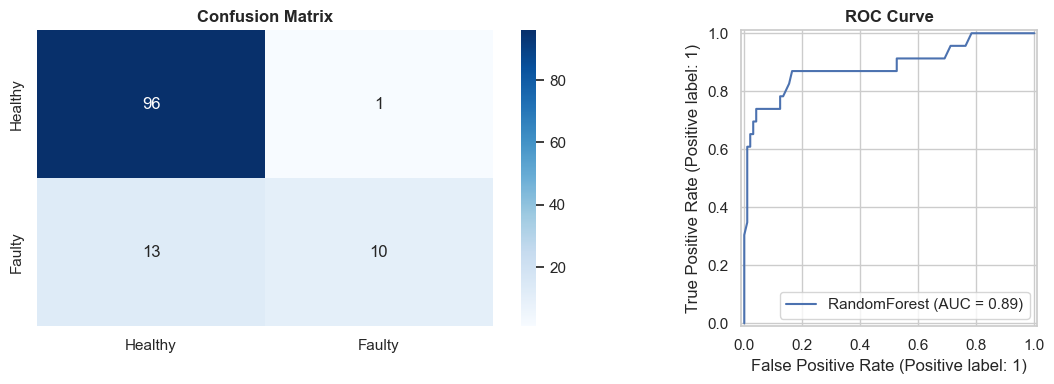

In [23]:
rf_t = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
rf_t.fit(X_tr_s, y_tr)
y_pred_t = rf_t.predict(X_te_s); y_prob_t = rf_t.predict_proba(X_te_s)[:,1]
print(classification_report(y_te, y_pred_t, target_names=['Healthy','Faulty']))
print(f'ROC-AUC: {roc_auc_score(y_te, y_prob_t):.4f}')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_te, y_pred_t)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy','Faulty'], yticklabels=['Healthy','Faulty'], ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
RocCurveDisplay.from_predictions(y_te, y_prob_t, ax=axes[1], name='RandomForest')
axes[1].set_title('ROC Curve', fontweight='bold')
plt.tight_layout(); plt.savefig('../data/processed/maintenance_rf.png', bbox_inches='tight')
plt.show()


---
## 5. Real APS Scania Data
Validating the pipeline on the real Scania truck APS failure dataset (~60k rows, 171 sensor features).


In [24]:
aps_path = '../data/raw/maintenance/aps_failure_training_set.csv'
aps_test_path = '../data/raw/maintenance/aps_failure_test_set.csv'
print('Loading APS training data ...')
aps = pd.read_csv(aps_path, skiprows=20, na_values=['na'])
print(f'APS train shape: {aps.shape}')
print(f'Class distribution:\n{aps["class"].value_counts().to_string()}')
aps_test = pd.read_csv(aps_test_path, skiprows=20, na_values=['na'])
print(f'APS test shape: {aps_test.shape}')


Loading APS training data ...
APS train shape: (60000, 171)
Class distribution:
class
neg    59000
pos     1000
APS test shape: (16000, 171)


In [25]:
# Label encoding
aps['label']      = (aps['class'] == 'pos').astype(int)
aps_test['label'] = (aps_test['class'] == 'pos').astype(int)
aps      = aps.drop(columns=['class'])
aps_test = aps_test.drop(columns=['class'])

# Drop columns with > 30% missing; fill rest with median
thresh = int(0.7 * len(aps))
aps      = aps.dropna(axis=1, thresh=thresh)
aps_test = aps_test[aps.columns]   # align test columns
medians  = aps.median(numeric_only=True)
aps      = aps.fillna(medians)
aps_test = aps_test.fillna(medians)

y_aps_tr = aps['label'].values;      X_aps_tr = aps.drop(columns=['label']).values
y_aps_te = aps_test['label'].values; X_aps_te = aps_test.drop(columns=['label']).values

sc_aps = StandardScaler()
X_aps_tr_s = sc_aps.fit_transform(X_aps_tr)
X_aps_te_s = sc_aps.transform(X_aps_te)

print(f'Features after cleaning: {X_aps_tr.shape[1]}')
print(f'Train failure rate: {y_aps_tr.mean():.2%}')
print(f'Test  failure rate: {y_aps_te.mean():.2%}')


Features after cleaning: 160
Train failure rate: 1.67%
Test  failure rate: 2.34%


APS Random Forest results:
              precision    recall  f1-score   support

         neg       1.00      0.99      0.99     15625
         pos       0.62      0.83      0.71       375

    accuracy                           0.98     16000
   macro avg       0.81      0.91      0.85     16000
weighted avg       0.99      0.98      0.99     16000

APS ROC-AUC: 0.9905


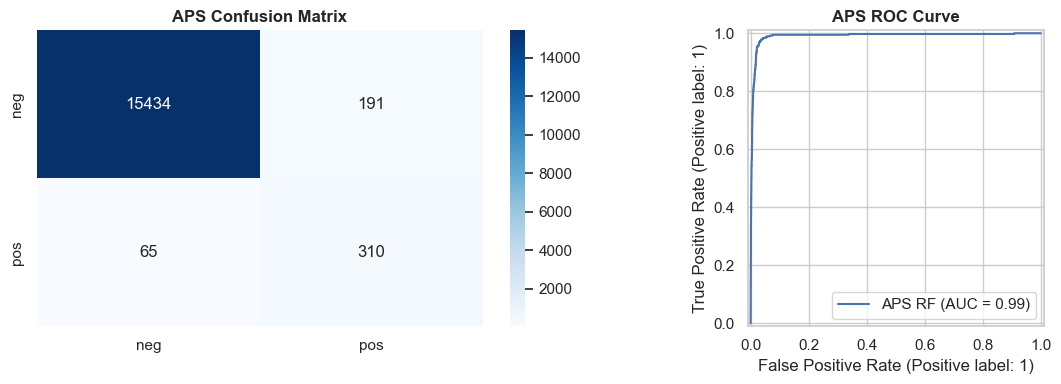

Saved → models/maintenance_aps.joblib


In [26]:
rf_aps = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   max_depth=15, n_jobs=-1, random_state=42)
rf_aps.fit(X_aps_tr_s, y_aps_tr)
y_aps_pred = rf_aps.predict(X_aps_te_s)
y_aps_prob = rf_aps.predict_proba(X_aps_te_s)[:,1]
print('APS Random Forest results:')
print(classification_report(y_aps_te, y_aps_pred, target_names=['neg','pos']))
print(f'APS ROC-AUC: {roc_auc_score(y_aps_te, y_aps_prob):.4f}')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm_aps = confusion_matrix(y_aps_te, y_aps_pred)
sns.heatmap(cm_aps, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg','pos'], yticklabels=['neg','pos'], ax=axes[0])
axes[0].set_title('APS Confusion Matrix', fontweight='bold')
RocCurveDisplay.from_predictions(y_aps_te, y_aps_prob, ax=axes[1], name='APS RF')
axes[1].set_title('APS ROC Curve', fontweight='bold')
plt.tight_layout(); plt.savefig('../data/processed/maintenance_aps.png', bbox_inches='tight')
plt.show()
joblib.dump({'model':rf_aps,'scaler':sc_aps,'n_features':X_aps_tr.shape[1]},
            'models/maintenance_aps.joblib')
print('Saved → models/maintenance_aps.joblib')


In [27]:
# Save telematics models for the maintenance service
joblib.dump({'model':iso,  'scaler':sc_t,'features':TEL_FEATURES}, 'models/maintenance_iso.joblib')
joblib.dump({'model':rf_t, 'scaler':sc_t,'features':TEL_FEATURES}, 'models/maintenance_rf.joblib')
print('Saved → models/maintenance_iso.joblib')
print('Saved → models/maintenance_rf.joblib')


Saved → models/maintenance_iso.joblib
Saved → models/maintenance_rf.joblib
